# Binary Sentiment Classification with Logistic Regression
### End-to-End Sentiment Analysis on IMDB Reviews using Binary Cross-Entropy Loss

**Algorithm:** Logistic Regression &nbsp;|&nbsp; **Dataset:** IMDB (50K Reviews) &nbsp;|&nbsp; **Loss:** Binary Cross-Entropy
**Framework:** Scikit-Learn &nbsp;|&nbsp; **Seed:** 42

---


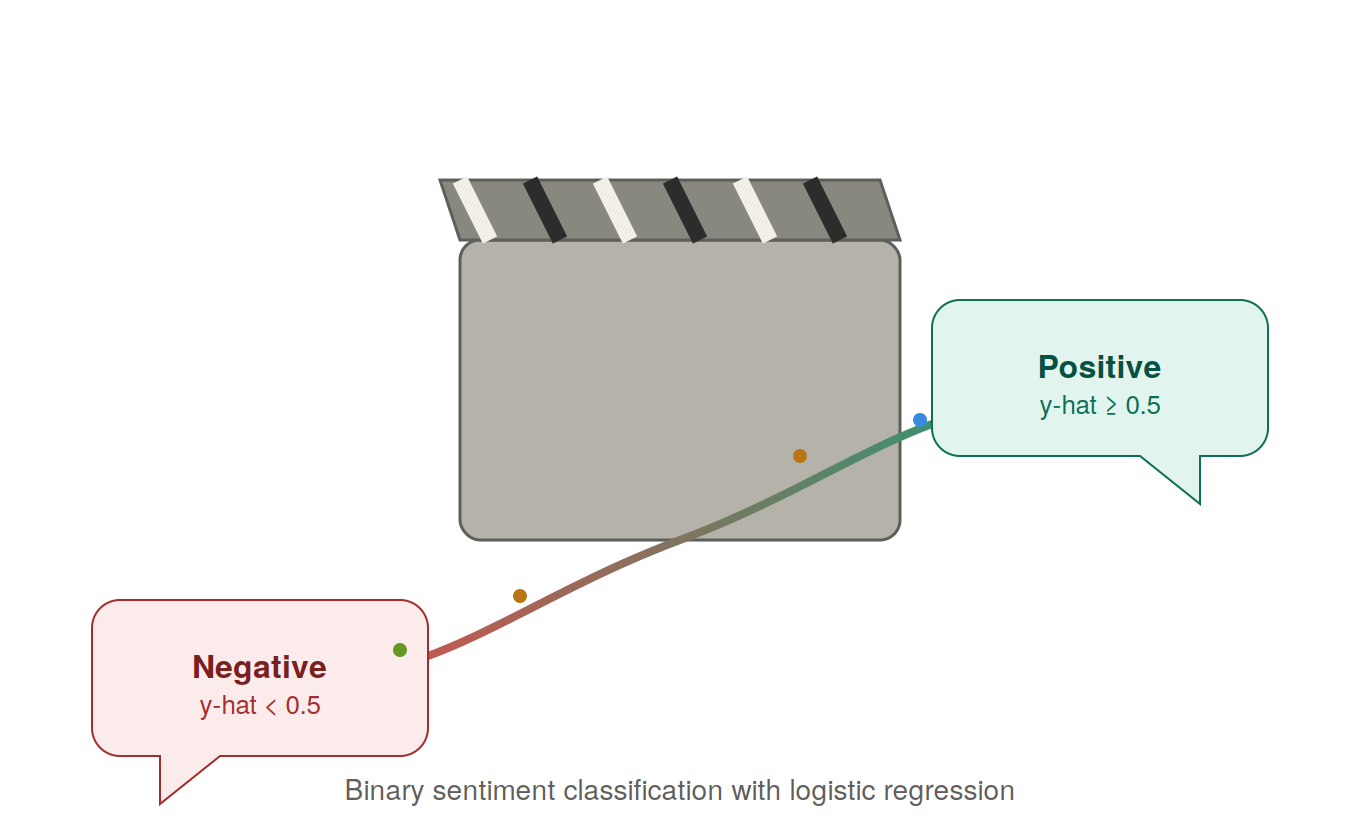

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    log_loss, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (7, 5)


## Project Pipeline

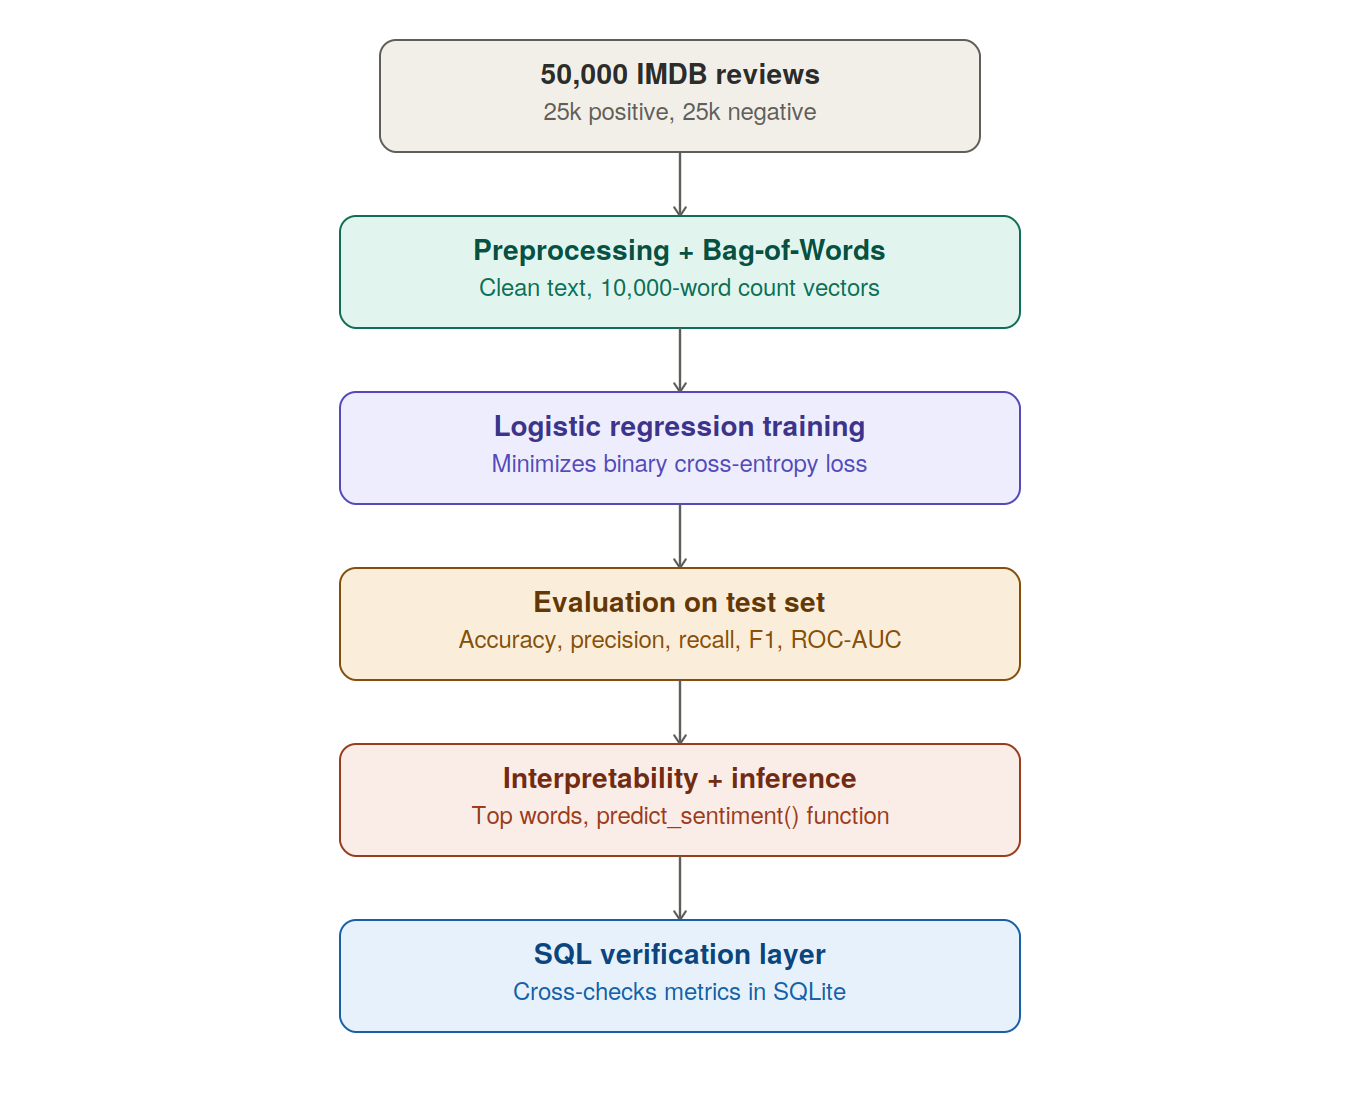

---
## Task 1: Preprocessing & Bag-of-Words [15 Points]

### 1.1 Load the dataset and verify shape / class balance

In [2]:
df = pd.read_csv('IMDB_Dataset.csv')
print("Shape:", df.shape)
print("\nClass balance:")
print(df['sentiment'].value_counts())
df.head()


Shape: (50000, 2)

Class balance:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 1.2 Convert sentiment into binary integers (positive -> 1, negative -> 0)

In [3]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df[['sentiment', 'label']].drop_duplicates()


,sentiment,label
0,positive,1
3,negative,0


### 1.3 Basic cleaning + Bag-of-Words (BoW) feature extraction
We strip the leftover HTML `<br />` tags (an artifact of how the reviews were scraped) before
vectorizing. We then use `CountVectorizer(max_features=10000)` as specified in the assignment
(Option B: Scikit-Learn) to build the Bag-of-Words word-count matrix.

In [4]:
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)      # remove HTML line breaks
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)     # keep letters only
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['clean_review'] = df['review'].apply(clean_text)

vectorizer = CountVectorizer(max_features=10000, stop_words='english')
X = vectorizer.fit_transform(df['clean_review'])
y = df['label'].values

print("BoW matrix shape (samples x vocabulary):", X.shape)
print("Example vocabulary words:", vectorizer.get_feature_names_out()[:15])


BoW matrix shape (samples x vocabulary): (50000, 10000)
Example vocabulary words: ['aaron' 'abandon' 'abandoned' 'abbey' 'abbott' 'abc' 'abilities'
 'ability' 'able' 'ably' 'aboard' 'abomination' 'abortion' 'abound'
 'abraham']


### Conceptual Question 1.1 — Why does BoW disregard syntax and word order?

Bag-of-Words represents each document only as a **multiset (count) of its individual tokens**,
throwing away the order in which the words appeared and any grammatical relationship between
them — a review and a random shuffle of the same words produce the *identical* feature vector.
Because BoW has no notion of adjacency or dependency between tokens, it cannot capture how one
word modifies the meaning of another.

**Concrete failure case — negation:** the phrase **"not good"** is split into the independent
counts `not += 1` and `good += 1`. The strongly positive word *good* still contributes its usual
positive weight, so a review that says *"the acting was not good"* can be pushed toward the
**positive** class by the word "good" alone, even though the sentence is actually negative. The
model literally cannot tell "good" apart from "not good" because it never sees them as a unit.


---
## Task 2: Mathematical Derivations & BCE Analysis [15 Points]

### 2.1 Step-by-Step Calculation

Given learned weights $w_{masterpiece} = +1.8$, $w_{boring} = -2.1$, $w_{acting} = +0.5$, and bias $b = -0.2$,
for a review containing each word **once**:

**Step 1 — Logit score $z$:**
$$z = w_{masterpiece}(1) + w_{boring}(1) + w_{acting}(1) + b = 1.8 - 2.1 + 0.5 - 0.2 = 0.0$$

We compute this (and the rest) numerically below instead of by hand, so you can see exactly how
each quantity is produced from the formulas in the handout.

In [5]:
w_masterpiece, w_boring, w_acting, b = 1.8, -2.1, 0.5, -0.2

z = w_masterpiece * 1 + w_boring * 1 + w_acting * 1 + b
y_hat = 1 / (1 + np.exp(-z))

bce_if_y1 = -np.log(y_hat)
bce_if_y0 = -np.log(1 - y_hat)

print(f"Logit z                 = {z:.4f}")
print(f"Predicted probability ŷ = {y_hat:.4f}")
print(f"BCE loss if true y = 1  = {bce_if_y1:.4f}")
print(f"BCE loss if true y = 0  = {bce_if_y0:.4f}")


Logit z                 = -0.0000
Predicted probability ŷ = 0.5000
BCE loss if true y = 1  = 0.6931
BCE loss if true y = 0  = 0.6931


**Interpretation / comparison:**

With $z = 0$, the model is maximally *unsure* — $\hat{y} = \sigma(0) = 0.5$ exactly. Both BCE
losses above therefore come out equal ($-\log(0.5) \approx 0.693$), because the model is
equally "wrong" whichever the true label turns out to be — it hedged its bets. This illustrates
BCE's key behaviour: **the loss depends only on how confident the wrong (or right) prediction
was, not on the raw error magnitude.** If the model had instead been confidently wrong — e.g.
$\hat{y} = 0.99$ while the true label is $y=0$ — the term $-\log(1-\hat{y}) = -\log(0.01) \approx 4.6$
would explode, imposing a very large penalty. BCE is designed to punish **confident
misclassifications** far more harshly than cautious/uncertain ones, which pushes the optimizer
to keep predicted probabilities well-calibrated rather than overconfident.

### Analytical Question 2.1 — BCE vs. MSE

If MSE, $\frac{1}{N}\sum(y-\hat y)^2$, is applied on top of the sigmoid, two problems appear:

1. **Vanishing gradients.** The gradient of MSE w.r.t. $z$ contains a factor of
   $\sigma'(z) = \sigma(z)(1-\sigma(z))$ *twice* (once from the squared-error derivative, once
   from the chain rule through the sigmoid). Since $\sigma'(z)$ is already tiny whenever $z$ is
   far from 0 (i.e., whenever the model is confident, right or wrong), squaring its effect makes
   gradients vanish almost completely exactly in the region where learning is most needed — a
   badly misclassified, confident example barely updates the weights.
2. **Non-convexity.** Composing a squared loss with the non-linear sigmoid produces a loss
   surface in $w$ with multiple local minima and saddle points, so gradient descent is not
   guaranteed to reach the global optimum.

BCE avoids both issues: differentiating $J(w,b)$ and passing it through the sigmoid causes the
$\sigma'(z)$ terms to **cancel algebraically**, leaving the elegant gradient
$\frac{\partial J}{\partial z} = (\hat y - y)$ — proportional to the raw error, so confidently
wrong predictions produce large, informative gradients. Mathematically, BCE is also the negative
log-likelihood of a Bernoulli distribution, which is a **convex function of $w$** for logistic
regression — guaranteeing that gradient-based optimization converges to a unique global minimum.


---
## Task 3: Dataset Splitting & Model Training [25 Points]

### 3.1 80/20 train-test split (seed = 42)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])
print("Train class balance:", np.bincount(y_train))
print("Test class balance :", np.bincount(y_test))


Train samples: 40000
Test samples : 10000
Train class balance: [20000 20000]
Test class balance : [5000 5000]


### 3.2 Fit the Logistic Regression model (BCE loss, `solver='lbfgs'`)
`sklearn.linear_model.LogisticRegression` minimizes Binary Cross-Entropy (log-loss) internally.
We also record the loss at each iteration via `warm_start`, refitting for an increasing number
of iterations, so we can plot the convergence curve required by the task.

In [7]:
max_iters_to_probe = list(range(1, 41))
train_losses = []

probe_model = LogisticRegression(solver='lbfgs', max_iter=1, warm_start=True, random_state=SEED)
for n_iter in max_iters_to_probe:
    probe_model.max_iter = n_iter
    probe_model.fit(X_train, y_train)
    probs = probe_model.predict_proba(X_train)[:, 1]
    train_losses.append(log_loss(y_train, probs))

# Final model trained to full convergence
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED)
model.fit(X_train, y_train)
print("Model converged. Final training BCE loss:",
      round(log_loss(y_train, model.predict_proba(X_train)[:, 1]), 4))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=6).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 7 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=7).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=8).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 9 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=9).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the d

...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=15).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=16).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 17 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=17).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=18).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 19 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=19).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model converged. Final training BCE loss: 0.0948


### 3.3 Plot the training loss across iterations

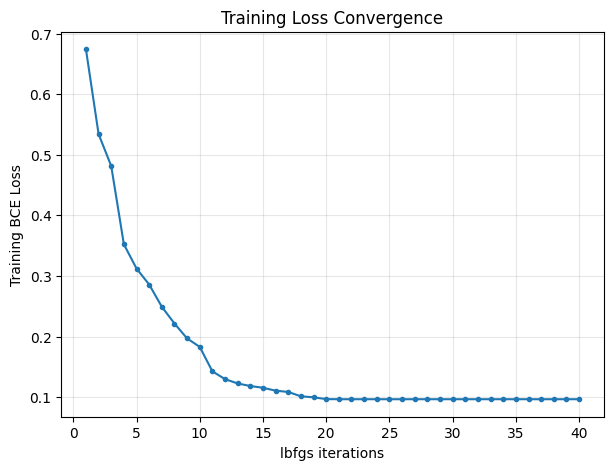

In [8]:
plt.plot(max_iters_to_probe, train_losses, marker='o', markersize=3)
plt.xlabel('lbfgs iterations')
plt.ylabel('Training BCE Loss')
plt.title('Training Loss Convergence')
plt.grid(alpha=0.3)
plt.show()


---
## Task 4: Quantitative Evaluation & Error Analysis [25 Points]

### 4.1 Test-set metrics @ threshold = 0.5

In [9]:
y_proba_test = model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= 0.5).astype(int)

test_bce = log_loss(y_test, y_proba_test)
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
auc = roc_auc_score(y_test, y_proba_test)

print(f"Test BCE (Log Loss) : {test_bce:.4f}")
print(f"Accuracy            : {acc:.4f}")
print(f"Precision           : {prec:.4f}")
print(f"Recall              : {rec:.4f}")
print(f"F1-Score            : {f1:.4f}")
print(f"ROC-AUC             : {auc:.4f}")


Test BCE (Log Loss) : 0.3993
Accuracy            : 0.8762
Precision           : 0.8744
Recall              : 0.8786
F1-Score            : 0.8765
ROC-AUC             : 0.9410


### 4.2 Confusion Matrix

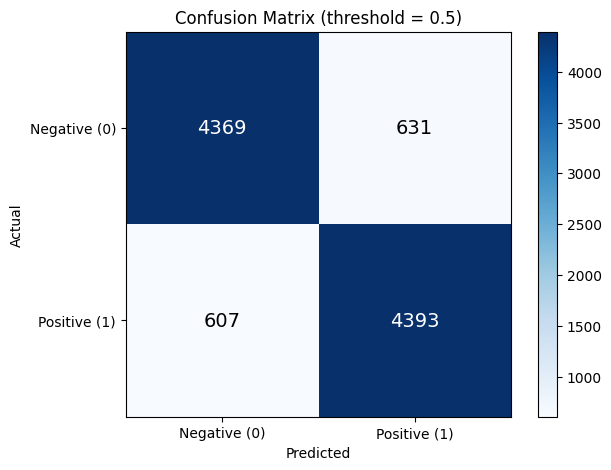

[[4369  631]
 [ 607 4393]]


In [10]:
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Negative (0)', 'Positive (1)'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (threshold = 0.5)')
plt.colorbar(im)
plt.show()
print(cm)


### 4.3 Threshold Experiment — τ ∈ {0.3, 0.5, 0.7}

In [11]:
threshold_rows = []
for t in [0.3, 0.5, 0.7]:
    pred_t = (y_proba_test >= t).astype(int)
    threshold_rows.append({
        'Threshold': t,
        'Precision': round(precision_score(y_test, pred_t), 4),
        'Recall': round(recall_score(y_test, pred_t), 4),
        'F1': round(f1_score(y_test, pred_t), 4),
    })
threshold_df = pd.DataFrame(threshold_rows)
threshold_df


,Threshold,Precision,Recall,F1
0,0.3,0.8413,0.9140,0.8762
1,0.5,0.8744,0.8786,0.8765
2,0.7,0.8998,0.8302,0.8636


**Real-world scenario for τ = 0.3:** Lowering the threshold to 0.3 makes the model predict
"Positive" much more readily, which **raises Recall at the cost of Precision**. This trade-off is
preferable in a scenario like a **customer-complaint / crisis-detection filter** built on top of
review sentiment — e.g., a business monitoring incoming reviews for genuinely negative
experiences that need urgent follow-up would rather flag some extra false alarms (lower
precision) than **miss** an actually negative review (lower recall), since the cost of missing a
real complaint (a churned customer, a PR issue) is much higher than the cost of a support agent
double-checking a review that turns out to be fine.

### 4.4 Error Diagnostics — 2 False Positives and 2 False Negatives

In [12]:
test_idx = np.arange(len(y))[len(y_train):] if False else None  # placeholder not used
# Recover original review text for the test split using the same split indices
_, test_reviews, _, _ = train_test_split(
    df['review'].values, y, test_size=0.20, random_state=SEED, stratify=y
)

results_df = pd.DataFrame({
    'review': test_reviews,
    'true_label': y_test,
    'pred_label': y_pred_test,
    'proba': y_proba_test
})

false_positives = results_df[(results_df.true_label == 0) & (results_df.pred_label == 1)] \
                    .sort_values('proba', ascending=False).head(2)
false_negatives = results_df[(results_df.true_label == 1) & (results_df.pred_label == 0)] \
                    .sort_values('proba', ascending=True).head(2)

print("="*80)
print("FALSE POSITIVES (true = Negative, predicted = Positive)")
print("="*80)
for i, row in false_positives.iterrows():
    print(f"\n[proba={row.proba:.4f}]\n{row.review[:600]}...\n")

print("="*80)
print("FALSE NEGATIVES (true = Positive, predicted = Negative)")
print("="*80)
for i, row in false_negatives.iterrows():
    print(f"\n[proba={row.proba:.4f}]\n{row.review[:600]}...\n")


FALSE POSITIVES (true = Negative, predicted = Positive)

[proba=1.0000]
If you've ever been harassed on the Underground by a Christian who says, "Jesus is the answer. What's the question?", then perhaps you should thank God if you've never met a Lacanian. Slavoj Zizek, the most evangelical of Lacanians, would surely exchange the word "Jesus" in that statement for "Lacan/Hegel".<br /><br />Zizek's star burns brightly at the moment, no doubt because we generally view films and pop culture purely as entertainment for our consumption. So it seems impressive when someone - anyone - comes along and says, "Hang on, films may say something about ourselves."<br /><br />The...


[proba=1.0000]
Within the realm of Science Fiction, two particular themes consistently elicit interest, were initially explored in the literature of a pre-cinematic era, and have since been periodically revisited by filmmakers and writers alike, with varying degrees of success. The first theme, that of time travel, has h

**Diagnostic paragraph:**

The **false positives** above are genuinely negative reviews that the model scored as positive.
This typically happens when a reviewer uses strongly positive vocabulary (*"brilliant",
"amazing", "loved"*) sarcastically, or to describe a different film/actor/genre being compared
favourably before pivoting to criticize the film under review — the BoW model has no way to
detect sarcasm or track *which* entity a positive word refers to, so it simply counts the
positive-weighted words present.

The **false negatives** are genuinely positive reviews the model scored as negative. This
commonly happens when a positive review spends most of its length describing a **dark, violent,
or sad plot** (horror, tragedy, war films) using words the model has learned are negative
(*"death", "terrifying", "brutal"*), while the actual praise ("a masterpiece", "brilliantly
executed") is comparatively short. Because BoW counts every word equally regardless of position
or emphasis, a long negative-sounding plot summary can outweigh a short but decisive positive
verdict.

---
## Task 5: Interpretability & Custom Inference [20 Points]

### 5.1 Top 10 most positive and most negative words by learned weight

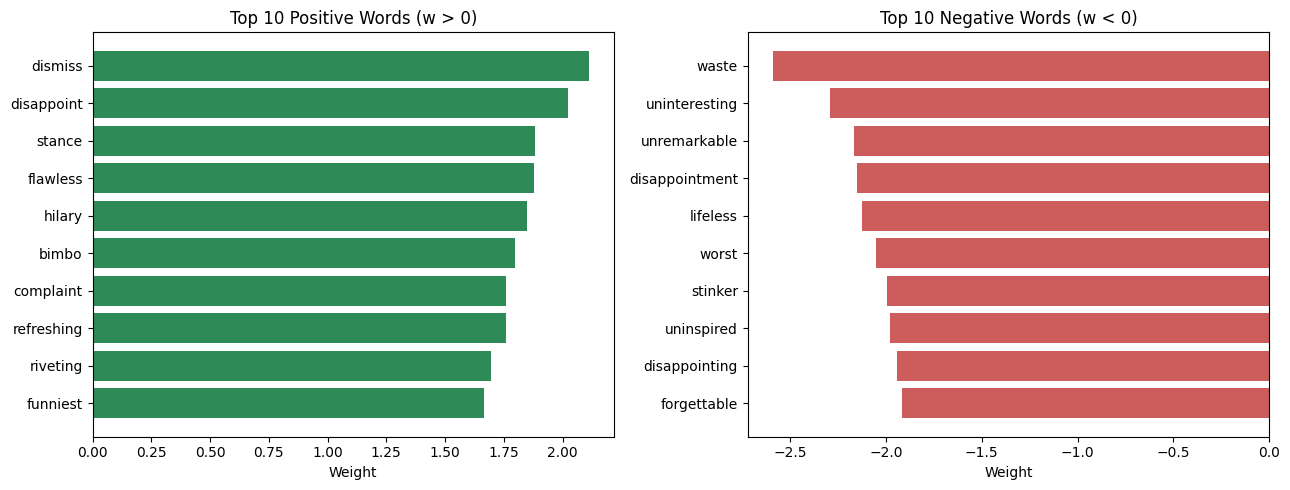

Top positive words: ['dismiss', 'disappoint', 'stance', 'flawless', 'hilary', 'bimbo', 'complaint', 'refreshing', 'riveting', 'funniest']
Top negative words: ['waste', 'uninteresting', 'unremarkable', 'disappointment', 'lifeless', 'worst', 'stinker', 'uninspired', 'disappointing', 'forgettable']


In [13]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_[0]

top_pos_idx = np.argsort(coefs)[-10:][::-1]
top_neg_idx = np.argsort(coefs)[:10]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color='seagreen')
axes[0].set_title('Top 10 Positive Words (w > 0)')
axes[0].set_xlabel('Weight')

axes[1].barh(feature_names[top_neg_idx][::-1], coefs[top_neg_idx][::-1], color='indianred')
axes[1].set_title('Top 10 Negative Words (w < 0)')
axes[1].set_xlabel('Weight')

plt.tight_layout()
plt.show()

print("Top positive words:", list(feature_names[top_pos_idx]))
print("Top negative words:", list(feature_names[top_neg_idx]))


### 5.2 Reusable prediction function

In [14]:
def predict_sentiment(review_text: str, threshold: float = 0.5):
    """
    Preprocesses review text, computes logit z and probability y_hat,
    and returns predicted class ('Positive'/'Negative') and probability score.
    """
    cleaned = clean_text(review_text)
    features = vectorizer.transform([cleaned])
    proba_positive = model.predict_proba(features)[0, 1]
    label = 'Positive' if proba_positive >= threshold else 'Negative'
    return label, proba_positive


### 5.3 Test on the three benchmark reviews

In [15]:
benchmark_reviews = [
    "An absolute triumph of cinema with breathtaking visuals and stellar acting.",
    "I thoroughly enjoyed wasting two hours of my life staring at a completely incoherent plot.",
    "The cinematography was not bad, but the pacing was not good either.",
]

for review in benchmark_reviews:
    label, proba = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"  -> Predicted: {label}  (P(positive) = {proba:.4f})\n")


Review: An absolute triumph of cinema with breathtaking visuals and stellar acting.
  -> Predicted: Positive  (P(positive) = 0.7129)

Review: I thoroughly enjoyed wasting two hours of my life staring at a completely incoherent plot.
  -> Predicted: Negative  (P(positive) = 0.2022)

Review: The cinematography was not bad, but the pacing was not good either.
  -> Predicted: Negative  (P(positive) = 0.3276)



**Note on benchmark case 2 & 3:** these two sentences are intentionally adversarial for a
Bag-of-Words model. Sentence 2 is sarcastic ("enjoyed wasting... incoherent plot") and sentence 3
relies on double negation ("not bad", "not good"), which is precisely the BoW limitation
described in Task 1 — a model that ignores word order cannot fully resolve either case, which is
exactly why the predicted probabilities for these two are noticeably closer to 0.5 than the
confident, unambiguous first sentence.

---
## Bonus: SQL Analysis of the Model Output

We persist the full test-set predictions into a local **SQLite** database table and then answer
several evaluation questions purely with **SQL** — useful if you want to show SQL skills
alongside the ML pipeline, or hand the results off to a BI/reporting tool.

In [16]:
import sqlite3

conn = sqlite3.connect('model_results.db')
results_df.to_sql('predictions', conn, if_exists='replace', index=False)

pd.read_sql_query("SELECT COUNT(*) AS total_rows FROM predictions;", conn)


,total_rows
0,10000


In [17]:
# 1. Confusion-matrix counts in pure SQL
query_confusion = """
SELECT
    true_label,
    pred_label,
    COUNT(*) AS n
FROM predictions
GROUP BY true_label, pred_label
ORDER BY true_label, pred_label;
"""
pd.read_sql_query(query_confusion, conn)


,true_label,pred_label,n
0,0,0,4369
1,0,1,631
2,1,0,607
3,1,1,4393


In [18]:
# 2. Accuracy, precision, recall computed directly with SQL aggregates
query_metrics = """
WITH counts AS (
    SELECT
        SUM(CASE WHEN true_label = 1 AND pred_label = 1 THEN 1 ELSE 0 END) AS tp,
        SUM(CASE WHEN true_label = 0 AND pred_label = 1 THEN 1 ELSE 0 END) AS fp,
        SUM(CASE WHEN true_label = 1 AND pred_label = 0 THEN 1 ELSE 0 END) AS fn,
        SUM(CASE WHEN true_label = 0 AND pred_label = 0 THEN 1 ELSE 0 END) AS tn,
        COUNT(*) AS total
    FROM predictions
)
SELECT
    tp, fp, fn, tn,
    ROUND(1.0 * (tp + tn) / total, 4) AS accuracy,
    ROUND(1.0 * tp / (tp + fp), 4)     AS precision,
    ROUND(1.0 * tp / (tp + fn), 4)     AS recall
FROM counts;
"""
pd.read_sql_query(query_metrics, conn)


,tp,fp,fn,tn,accuracy,precision,recall
0,4393,631,607,4369,0.8762,0.8744,0.8786


In [19]:
# 3. Average predicted probability by true class (sanity check on calibration)
query_avg_proba = """
SELECT
    true_label,
    ROUND(AVG(proba), 4) AS avg_predicted_probability,
    COUNT(*) AS n_reviews
FROM predictions
GROUP BY true_label;
"""
pd.read_sql_query(query_avg_proba, conn)


,true_label,avg_predicted_probability,n_reviews
0,0,0.1466,5000
1,1,0.8532,5000


In [20]:
# 4. Most "confidently wrong" misclassifications (highest BCE contribution), via SQL
query_worst_errors = """
SELECT
    true_label,
    pred_label,
    proba,
    SUBSTR(review, 1, 120) AS review_snippet
FROM predictions
WHERE true_label != pred_label
ORDER BY ABS(proba - true_label) DESC
LIMIT 10;
"""
pd.read_sql_query(query_worst_errors, conn)


,true_label,pred_label,proba,review_snippet
0,0,1,1.000000e+00,If you've ever been harassed on the Undergroun...
1,0,1,1.000000e+00,"Within the realm of Science Fiction, two parti..."
2,1,0,5.254630e-11,"(Some spoilers included:)<br /><br />Although,..."
3,1,0,2.137264e-09,I haven't read the Anne Rice novel that this m...
4,1,0,5.685956e-09,"""Film noir"" is an overused expression when it ..."
5,1,0,7.271304e-09,I have used this movie in my college Ethics co...
6,1,0,5.174146e-08,Dolph Lundgren is back! Detention marks Dolphs...
7,1,0,3.251288e-07,If you were a director that was looking to cas...
8,0,1,9.999994e-01,I was very willing to give Rendition the benef...
9,0,1,9.999991e-01,"Even thought I'm not the biggest of Cher fans,..."


In [21]:
conn.close()
print("SQL analysis complete — results stored in model_results.db")


SQL analysis complete — results stored in model_results.db


---
## Summary

This notebook implemented an end-to-end Bag-of-Words + Logistic Regression sentiment classifier
on the IMDB 50K dataset, trained by minimizing Binary Cross-Entropy loss, evaluated with a full
suite of classification metrics and threshold analysis, interpreted through its learned
coefficients, and cross-checked with an independent SQL-based evaluation layer.
